In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from num_kernels import NumKernels, PLaxfromClass
from scipy.special import sici
import vegas
import functools

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

def mm(cc, cx, xx, fx=0.1):
    return (1-fx)**2 *cc+fx*(1-fx)*cx+fx**2 * xx

----
integrate the mm 

In [60]:
fx=0.2
ma=1.e-26
zeval=0.5
h=0.67810
p=2

# kevList=np.logspace(np.log10(0.05),np.log10(0.6),60)
kevList = np.arange(0.03,0.6,0.02)

plclass = PLaxfromClass(fx=fx, m_a_ev=ma, zeval=zeval)
kref =8.4e12 * pow(ma/h,1/2) * 0.666**0.25

k4int = np.logspace(-4,1,500)
nk = NumKernels(fx=fx, kref=kref, fullt=np.linspace(-3,3,10), rtol=0.001, p=p)

Tx = nk.g_an(-(2+p)*np.log(k4int/kref))
Pm_ev = plclass.PLc_int(k4int) * mm(1,Tx, Tx**2)
PLm_int = interp1d(k4int, Pm_ev, kind='cubic', fill_value="extrapolate")


In [61]:
fact=(2*np.pi)**3
def training_int(vars,kev):
    logq=vars[0]
    q = np.exp(logq)
    mu=vars[1]

    P13dmdm=6*q*q*(nk.F3_0(kev,q,mu))*PLm_int(q)*PLm_int(kev)

    kMq = np.sqrt(kev*kev + q*q - 2*kev*q*mu)
    kPq = np.sqrt(kev*kev + q*q + 2*kev*q*mu)
    P22dmdm=0
    if kMq>q:
        P22dmdm+=2*q*q*(nk.F2_0(kev,q,mu)**2)*PLm_int(q)*PLm_int(kMq)
    if kPq>q:
        P22dmdm+=2*q*q*(nk.F2_0(kev,q,-mu)**2)*PLm_int(q)*PLm_int(kPq)
    intf=4*q*np.pi/fact
    return [intf*P22dmdm,intf*P13dmdm]

In [62]:
dmdm1l = []
for kEval in kevList:
    integ = vegas.Integrator([[np.log(1.e-3), np.log(5.)], [0., 1.]],mpi=True, nproc=70)
    dmdm22,dmdm13 = integ(functools.partial(training_int, kev=kEval),neval=1000)
    dmdm1l.append(dmdm22.mean + dmdm13.mean)
    print(f'{kEval} {dmdm22} {dmdm13}', flush=True, end='\r')

In [63]:
resfile = '/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/linearkbinning/P13-ma26p0-fx0p2-N5000-p2.txt'

k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(resfile.replace('P13','P22'), unpack=True)
k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(resfile.replace('P22','P13'), unpack=True)



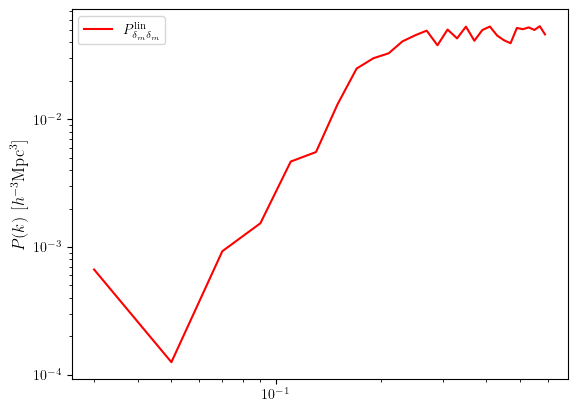

In [65]:

# Upper panel

# plt.plot(k, PL_cc+dcdc22_EdS +dcdc13_EdS, 'k', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)


# plt.plot(k, PL_cc+dcdc22 +dcdc13, 'r', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)
# plt.plot(k, PLm_int(k), 'g--', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)
term_1l_proper =  mm(dcdc22,dcdx22,dxdx22)+ mm(dcdc13,dcdx13,dxdx13)
Pm_1l_proper = PL_cc*mm(1,TL_x, TL_x**2)+  mm(dcdc22,dcdx22,dxdx22)+ mm(dcdc13,dcdx13,dxdx13)
# plt.plot(k, Pm_1l_proper, 'm', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)

term_1l_naive = np.array(dmdm1l)
Pm_1l_naive = PLm_int(k)+np.array(dmdm1l)
# plt.plot(k, Pm_1l_naive, 'g', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)

plt.plot(k,np.abs(Pm_1l_proper/Pm_1l_naive-1), 'r', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)

plt.xscale('log')
plt.yscale('log')

plt.legend(fontsize=10, loc='best', ncol=2)
plt.ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)


plt.show()

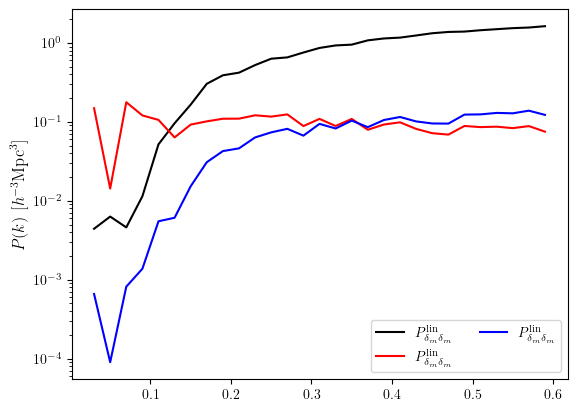

In [67]:

# Upper panel
plt.plot(k,np.abs(term_1l_naive/PLm_int(k)), 'k', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)

plt.plot(k,np.abs(term_1l_proper/term_1l_naive-1), 'r', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)


plt.plot(k,np.abs(term_1l_proper/term_1l_naive-1)*np.abs(term_1l_naive/PLm_int(k)), 'b', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)


# plt.xscale('log')
plt.yscale('log')

plt.legend(fontsize=10, loc='best', ncol=2)
plt.ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)


plt.show()

---
attach the errorbars

In [69]:
# compute number of modes
V_bin = 1*(1000**3)

# logarithmic binning--------
# logk=np.log10(kevList)
# Dlogk=np.diff(logk)[1] #should be all equal
# kplus=10**(logk+Dlogk/2)
# kminus=10**(logk-Dlogk/2)
# Nk = V_bin/(6*np.pi**2)*(kplus**3 - kminus**3)

# linear binning--------
Dk=np.diff(kevList)[1] #should be all equal
kplus=kevList+Dk/2
kminus=kevList-Dk/2

Nk = V_bin/(6*np.pi**2)*(kplus**3 - kminus**3)


print(f'Check N_k={Nk[0]}')

C_gauss = 2/Nk*(Pm_1l_naive**2)
v_gauss = np.sqrt(C_gauss)



Check N_k=945.6643806618192


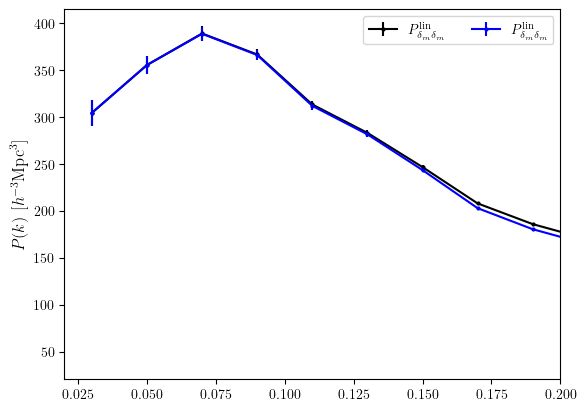

In [76]:
plt.errorbar(k, k*Pm_1l_proper, yerr=k*v_gauss, c='k', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', marker='o', markersize=2)

plt.errorbar(k, k*Pm_1l_naive,  yerr=k*v_gauss, c='b', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', marker='o', markersize=2)

# 
# plt.xscale('log')
# plt.yscale('log')
plt.xlim([0.02,0.2])

plt.legend(fontsize=10, loc='best', ncol=2)
plt.ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)


plt.show()

In [58]:
len(np.arange(0.03,0.6,0.02))

29